# Finite Volume Methods

## Hyperbolic Conservation Laws

Sebelum kita membahas secara spesifik **metode volume hingga**, kita akan terlebih dahulu mengeksplorasi kelas persamaan diferensial parsial (PDE) yang disebut **hukum konservasi hiperbolik**. 

Persamaan-persamaan ini secara umum menggambarkan pergerakan suatu kuantitas fisik yang harus dijaga konservasinya. Contoh kuantitas yang dikonservasi meliputi massa, momentum, atau energi.

### Conservation of Mass
Bayangkan sebuah fluida yang mengalir di dalam sebuah pipa sempit. Kita akan menggunakan $q$ untuk menyatakan **densitas** fluida tersebut dan $u$ untuk menyatakan **kecepatannya**. Kedua variabel ini merupakan fungsi dari ruang dan waktu:
$$
q = q(x, t), \quad u = u(x, t)
$$
Massa total yang terdapat dalam segmen pipa $[x_1, x_2]$ adalah
$$
\int_{x_1}^{x_2} q(x, t) \, dx \tag{1}
$$


Massa total ini dapat berubah terhadap waktu karena fluida mengalir masuk atau keluar dari bagian pipa ini. Kita sebut laju aliran massa masuk (atau keluar) dari interval $[x_1, x_2]$ pada waktu $t$ adalah

$$ f(q(x_1, t))) - f(q(x_2, t)). $$

Kita baru saja mengatakan bahwa laju aliran ini harus sama dengan laju perubahan terhadap waktu dari massa total; yaitu

$$\frac{d}{dt}\int_{x_1}^{x_2} q(x,t)\,dx = f(q(x_1,t)) - f(q(x_2,t)).$$

Dengan mengasumsikan fungsi-fungsinya kontinu (cukup), kita dapat menuliskan

$$\int_{x_1}^{x_2} \frac{\partial}{\partial x} f(q)\,dx = f(q(x_2,t)) - f(q(x_1,t))$$

dan karena itu kita dapat menuliskan ulang hukum konservasi sebagai

$$\frac{d}{dt}\int_{x_1}^{x_2} q(x,t)\,dx = - \int_{x_1}^{x_2}\frac{\partial}{\partial x} f(q)\,dx.$$

Dengan asumsi halus tertentu pada $q$, kita dapat memindahkan turunan terhadap waktu ke dalam integral. Kita juga akan menempatkan semuanya di sisi kiri, untuk memperoleh
$$
    \int_{x_1}^{x_2} \left(\frac{\partial}{\partial t}q(x,t) + \frac{\partial}{\partial x} f(q)\right) dx = 0.
$$

Karena integral ini bernilai nol untuk *setiap* pilihan $x_1,x_2$, maka haruslah bahwa integrannya (ekspresi di dalam tanda kurung) sebenarnya sama dengan nol *di mana-mana*! Oleh karena itu kita dapat menuliskan **differential conservation law**
$$
    q(x,t)_t + f(q(x,t))_x = 0.
$$

Persamaan ini menyatakan bahwa massa total terkonservasi -- karena secara lokal massa hanya dapat berubah akibat adanya aliran masuk atau keluar bersih.

### Advection 

Untuk menyelesaikan hukum konservasi di atas, kita memerlukan ekspresi untuk fluks, $f$. Laju aliran tersebut hanyalah massa dikali kecepatan: $f=u q$. Maka kita memperoleh **continuity equation**
$$
    q_t + (uq)_x = 0.
$$

Secara umum, kita membutuhkan persamaan lain untuk menentukan kecepatan $u(x,t)$. Nanti kita akan melihat persamaan lengkap dinamika fluida, tetapi untuk saat ini kita pertimbangkan kasus paling sederhana, di mana seluruh fluida mengalir pada satu kecepatan tunggal yang konstan, $u(x,t)=a$. Maka persamaan kontinuitas menjadi *persamaan adveksi*

$$q_t + a q_x = 0.$$

Kita sudah melihat bahwa solusi untuk persamaan adveksi adalah $$q(x,t) = q_0(x-at).$$  Mari kita plot solusi persamaan adveksi pada interval $[0,1]$ untuk kondisi awal $$q_0(x) = e^{-2(x-1/2)^2}.$$

In [ ]:
# Grid
x = numpy.linspace(0, 1, 1000) 

# Advection speed
a = 1.0                    

# Initial condition
def q_0(x):
    return numpy.exp(-200.*(x-0.2)**2)

figs = []
for t in numpy.linspace(0,1):
    figs.append(plt.figure(figsize=(8, 4)))
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, q_0(x - a * t), linewidth=2)
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.1, 1.1))
    axes.set_xlabel("$x$")
    axes.set_ylabel("$q(x,t)$")
    axes.set_title("Solution to the advection equation")
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

Seperti yang bisa kamu lihat, pulsa awal hanya bergerak ke kanan dengan kecepatan $a$ seiring bertambahnya waktu. Ini mungkin tidak terlalu menarik, tetapi ia menangkap fitur terpenting dari persamaan hiperbollik: gelombang merambat dengan kecepatan hingga.  

### Finite Volume Method for Advection

Kita bisa menyelesaikan persamaan adveksi secara tepat dengan mudah. Tetapi persamaan adveksi adalah prototipe untuk hukum konservasi yang lebih rumit, yang nantinya hanya akan bisa kita selesaikan secara kira-kira dengan menggunakan metode numerik. Untuk lebih memahami metode-metode tersebut, kita akan membahasnya terlebih dahulu dalam konteks persamaan adveksi.  

Untuk kesederhanaan, kita asumsikan bahwa kita ingin menyelesaikan persamaan adveksi pada interval $[0,1]$. Kita memperkenalkan kumpulan *grid cells* yang berjarak sama dengan lebar $\Delta x$, dan menuliskan $x_i$ untuk menunjukkan pusat sel $i$. Maka sel pertama adalah interval $[0,\Delta x]$ dan $x_1=\Delta x/2$. Kita juga akan menuliskan $x_{i-1/2}$ atau $x_{i+1/2}$ untuk menyatakan batas kiri atau batas kanan dari sel $i$, masing-masing.  

Kita menuliskan $Q_i$ untuk menyatakan nilai *rata-rata* dari solusi pada sel $i$:
$$
Q_i = \frac{1}{\Delta x} \int_{x_{i-1/2}}^{x_{i-1/2}} q \ dx.
$$  

Metode finite volume yang paling sederhana diperoleh dengan mengasumsikan bahwa solusi sebenarnya *sama dengan* $Q_i$ untuk seluruh sel $i$.  

Dengan menerapkan beda maju terhadap waktu, kita memperoleh *upwind method*

$$
    Q^{n+1}_i = Q^n_i -\frac{a \Delta t}{\Delta x}\left(Q_i - Q_{i-1}\right).
$$

Tentu saja, ini juga merupakan upwind method yang sama yang kita turunkan ketika mempertimbangkan finite differences.

In [ ]:
a = 1.0

m = 100
delta_x = 1.0 / float(m)
x = numpy.arange(-delta_x / 2.0, 1.0 + delta_x / 2.0, delta_x)

t = 0.0
T = 0.5
CFL = 0.8
delta_t = CFL * delta_x / a

# Initial data
def q_0(x):
    return numpy.exp(-200.*(x-0.2)**2)
Q = q_0(x)
Q_new = Q.copy()

figs = []
while t < T:
    # Incoming wave
#     Q_new[0] = numpy.sin(20.0 * numpy.pi * t)
    # Extrapolation BCs
    Q_new[0] = Q_new[1]
    
    Q_new[1:] = Q[1:] - a * delta_t / delta_x * (Q[1:] - Q[:-1])
    
    Q = Q_new.copy()
    t = t + delta_t
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, q_0(x - a * t), 'k', linewidth=2, label="True Solution")
    axes.plot(x, Q, 'o-', linewidth=2, label="Upwind")
    axes.set_title('t = %s' % str(t))
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-1.1, 1.1))
    axes.set_xlabel("$x$")
    axes.set_ylabel("$q(x,t)$")
    axes.set_title("Upwind Method")
    axes.legend(loc=4)
    plt.close(figs[-1])

# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

plt.show()

Kita bisa melihat bahwa kita memilih $\Delta t$ berdasarkan kondisi CFL yang kita turunkan untuk metode beda hingga. Hal yang sama berlaku di sini (bahkan kita menggunakan metode yang sama).  

Perhatikan bagaimana kita menyiapkan sebuah grid yang memuat satu sel ekstra di setiap ujung, di luar domain masalah $[0,1]$. Sel-sel ini disebut *ghost cells* dan sering berguna dalam menangani solusi di batas-batas grid.  

Teknik yang kita gunakan untuk menetapkan nilai ghost cell di atas, yaitu dengan menyalin nilai terakhir di dalam grid ke ghost cell, dikenal sebagai *zero-order extrapolation*. Ini berguna agar gelombang dapat melewati keluar domain (yang disebut *non-reflecting* boundaries). Perhatikan bahwa kita sebenarnya tidak perlu ghost cell di ujung kanan untuk metode upwind, tetapi untuk metode-metode lain kita akan membutuhkannya.  

Metode upwind itu sederhana, tetapi tidak terlalu akurat. Perhatikan bagaimana solusi yang dihitung menjadi lebih lebar dan lebih pendek dari waktu ke waktu. Perilaku ini disebut *dissipation*.  

#### Exercises

Sekarang lakukan hal berikut dengan kode di atas:

1. Set $m=1000$ atau lebih, lalu perhatikan bahwa butuh beberapa waktu untuk menghitung solusinya. Ubah loop bagian dalam (over $i$) menjadi satu baris tanpa loop, menggunakan numpy slicing. Untuk nilai $m$ yang besar, kode dengan slicing jauh lebih cepat.
2. Perhatikan bahwa langkah terakhir dari simulasi melewati waktu $T$. Ubah kode sehingga langkah terakhir disesuaikan agar tepat mencapai $T$.
3. Ubah kode sehingga animasi solusi terhadap waktu diplot. Kamu akan ingin mengumpulkan frame-frame solusi dalam sebuah list, lalu menggunakan jenis kode yang sama seperti yang kita gunakan di atas untuk menganimasikan solusi eksak.
4. Tambahkan beberapa kode untuk memplot solusi eksak.
5. Ubah kondisi batas kiri sehingga ada gelombang sinusoidal yang masuk dari kiri:
$$u(0,t) = \sin(20 \pi t).$$
Apa yang kamu perhatikan tentang sinusoid saat bergerak masuk ke dalam domain?

## Alternative Derivations

Cara lain untuk melihat finite volume methods adalah secara lebih langsung sebagai diskretisasi dari PDE:
$$
    \frac{d}{dt} \int_{x_1}^{x_2} q(x,t) dx = f(q(x_1,t)) - f(q(x_2,t)).
$$
menjadi
$$
    Q_i^{n+1} = Q^n_i - \frac{\Delta t}{\Delta x} \left [ F^n_{i+1/2} - F^n_{i-1/2} \right]
$$

Jika fluks dari sisi kiri sel $i$ menyatakan bahwa nilai $Q^n_{i-1}$ bergerak masuk dengan kecepatan $\lambda$, maka nilai itu akan menempuh $\lambda \Delta t$ dari panjang total sel $i$, sehingga meninggalkan sisa panjang $\Delta x - \lambda \Delta t$ dengan nilai semula $Q^n_i$. Mengambil rata-rata dari dua nilai ini untuk memperoleh $Q^{n+1}_{i}$ menghasilkan

$$\begin{aligned}
    Q^{n+1}_i &= \frac{Q^n_i (\Delta x - \lambda \Delta t) + Q^n_{i-1} \lambda \Delta t}{\Delta x} \\
    &=Q^n_i - \frac{\lambda \Delta t}{\Delta x} [Q^n_i - Q^n_{i-1}],
\end{aligned}$$

secara tepat menghasilkan metode up-wind!

## Traffic Flow

Sebagai contoh ilustrasi, kita sekarang akan mempertimbangkan hukum kekekalan skalar tertentu, yaitu model sederhana untuk arus lalu lintas. Model ini terkadang disebut sebagai model lalu lintas Lighthill-Whitham-Richards (atau LWR). Dari persamaan kontinuitas di atas, kita mengetahui:

$$q_t + (uq)_x = 0.$$

Sekarang kita akan menganggap $q$ sebagai densitas (kepadatan) mobil di jalan raya yang melaju dengan kecepatan $u$. Perhatikan bahwa kita tidak melacak mobil secara individual, melainkan hanya jumlah rata-rata mobil per unit panjang jalan. Dengan demikian, $q=0$ merepresentasikan ruas jalan yang kosong, dan kita dapat memilih satuan sedemikian rupa sehingga $q=1$ merepresentasikan kemacetan total (bumper-to-bumper).

Kita juga akan memilih satuan agar batas kecepatan adalah $u_\text{max}=1$, dan berasumsi bahwa pengemudi tidak pernah berkendara lebih cepat dari ini. Jika kita berasumsi bahwa pengemudi selalu melaju dengan kecepatan seragam yang tunggal, kita akan mendapatkan kembali persamaan adveksi. Namun kita semua tahu bahwa hal tersebut tidak akurat dalam praktiknya — mobil melaju lebih cepat saat lalu lintas lancar dan lebih lambat saat terjadi kemacetan. Cara termudah untuk memasukkan efek ini adalah dengan membuat kecepatan menjadi fungsi yang menurun secara linear terhadap densitas:

$$u(q) = 1 - q.$$

Perhatikan bahwa $u$ menuju nol saat $q$ mendekati densitas maksimum 1, sementara $u$ menuju nilai maksimum 1 saat densitas lalu lintas mendekati nol. Jelas bahwa baik $q$ maupun $u$ harus selalu berada dalam interval $[0,1]$. Dengan menggabungkan kedua persamaan di atas, hukum kekekalan kita menyatakan:

$$q_t + (q (1-q))_x = 0.$$

Fungsi $q(1-q)$ adalah fluks, atau laju aliran mobil. Perhatikan bagaimana fluks bernilai nol ketika tidak ada mobil dan juga ketika jalan sudah penuh sepenuhnya. Aliran lalu lintas maksimum sebenarnya terjadi ketika jalan terisi setengah penuh:

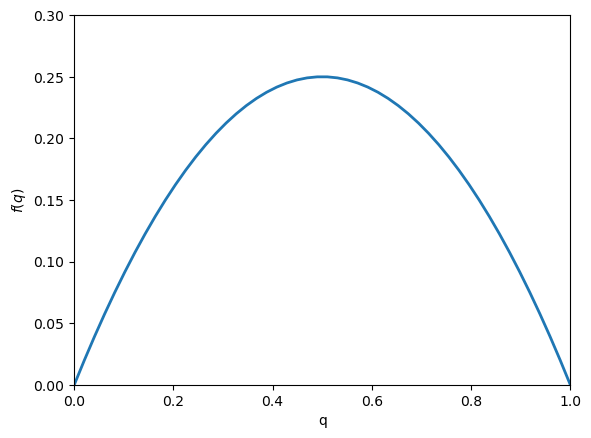

In [9]:
q = numpy.linspace(0, 1)
f = q * (1.0 - q)
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(q,f,linewidth=2)
axes.set_xlabel('q')
axes.set_ylabel('$f(q)$')
axes.set_xlim((0, 1))
axes.set_ylim((0.0, 0.3))
plt.show()

### Shock waves (traffic jams)

Persamaan ini secara fundamental berbeda dari persamaan adveksi karena fluksnya bersifat **nonlinier**. Fakta ini akan memberikan konsekuensi drastis baik pada perilaku solusi maupun pada metode numerik kita. Namun, secara superfisial kita dapat membuat persamaan ini terlihat seperti persamaan adveksi dengan menggunakan aturan rantai untuk menuliskan:

$$f(q)_x = f'(q) q_x = (1-2q)q_x.$$

Sehingga kita memperoleh:

$$q_t + (1-2q)q_x = 0.$$

Ini serupa dengan persamaan adveksi, tetapi dengan kecepatan $1-2q$ yang bergantung pada densitas mobil. Nilai $f'(q)=1-2q$ disebut sebagai *kecepatan karakteristik*. Kecepatan karakteristik ini bukanlah kecepatan gerak mobil (perhatikan bahwa nilainya bahkan bisa negatif!). Sebaliknya, ini adalah kecepatan di mana *informasi* merambat di sepanjang jalan.



### Shock waves (traffic jams)

Mari kita gunakan *metode Lax-Friedrichs* untuk menyelesaikan model lalu lintas LWR.

In [ ]:
m = 100
delta_x = 1.0 / m
x = numpy.arange(-delta_x / 2.0, 1.0 + delta_x / 2.0, delta_x)

t = 0.0
T = 0.5
CFL = 0.9
delta_t = CFL * delta_x

Q = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new = numpy.empty(Q.shape)
Q_list = [Q]

figs = []
while t < T:
    
    Q_new[1:-1] = 0.5 * (Q[:-2] + Q[2:]) - 0.5 * delta_t / delta_x \
                                               * (Q[2:] * (1.0 - Q[2:]) - Q[:-2] * (1.0 - Q[:-2]))
    
    Q = Q_new.copy()
    Q[0] = Q[-2]
    Q[-1] = Q[1]
    t += delta_t
    
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, Q, 'o-', linewidth=2)
    axes.set_title('Lax-Friedrichs Method - Traffic Flow at t = %s' % str(t))
    axes.set_xlabel("$x$")
    axes.set_ylabel("$q(x,t)$")
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-0.1, 1.1))
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

Berawal dari distribusi mobil yang mulanya mulus, kita melihat bahwa solusinya berkembang menjadi sesuatu yang tidak kontinu! Apa yang sebenarnya terjadi?

Secara alami, mobil-mobil di wilayah dengan densitas rendah di belakang puncak awalnya melaju lebih cepat daripada mobil-mobil di wilayah yang paling padat di depan mereka. Hal ini menyebabkan penajaman (steepening) pada bagian belakang aliran lalu lintas, dan akhirnya terjadi kemacetan: mobil-mobil yang datang dari belakang memiliki jalan yang terbuka, hingga tiba-tiba mereka mencapai area yang sangat padat dan harus menginjak rem secara mendadak. Terasa akrab, bukan?



#### Exercises

1. Ingat kembali diskusi kita mengenai kondisi CFL untuk adveksi. Untuk menerapkan kondisi CFL pada masalah nonlinier, kita menggunakan kecepatan karakteristik (dalam hal ini $1-2q$) sebagai pengganti kecepatan $a$. Untuk masalah ini, seberapa besar langkah waktu (*time step*) yang dapat kita ambil tanpa melanggar kondisi CFL?

2. Pada sel di bawah, atur parameter untuk mencari tahu apa yang terjadi ketika mobil mencapai lampu merah. Letakkan lampu merah di $x=1$ dan tetapkan $q=1$ pada interval $0.8<x<1$ di dekat lampu tersebut (mobil-mobil akan berhenti, saling berhimpitan di sana). Di sisa domain lainnya, tetapkan $q=0.2$, yang sesuai dengan lalu lintas lancar. Pada *ghost cell* di batas kanan, tetapkan $q=1$; pada *ghost cell* di sebelah kiri tetapkan $q=0.2$. Setelah Anda menghitung solusinya, periksa kembali dengan intuisi Anda. Apakah hasilnya masuk akal?

### Speed of a shock wave: the Rankine-Hugoniot conditions

Pada latihan kedua di atas, Anda seharusnya melihat sebuah gelombang kejut (*shock wave* atau diskontinuitas) yang bergerak ke kiri seiring bertambahnya mobil yang menumpuk di belakang lampu merah. Seberapa cepat diskontinuitas ini bergerak ke kiri?

Kita dapat mengetahuinya dengan menempatkan garis imajiner pada lokasi gelombang kejut tersebut. Misalkan $q_l$ adalah densitas mobil tepat di sebelah kiri garis, dan $q_r$ adalah densitas mobil tepat di sebelah kanan. Bayangkan sejenak garis tersebut diam (stasioner). Maka laju mobil yang mencapai garis dari kiri adalah $f(q_l)$ dan laju mobil yang meninggalkan garis ke kanan adalah $f(q_r)$. Jika garis itu benar-benar diam, kita harus memiliki $f(q_l) - f(q_r) = 0$ agar tidak ada penumpukan mobil di garis tersebut.

Namun, karena gelombang kejut tersebut tidak diam, maka garis tersebut bergerak. Misalkan $s$ adalah kecepatan gelombang kejut tersebut. Saat garis bergerak ke kiri, beberapa mobil yang tadinya di sebelah kiri sekarang berada di sebelah kanan garis. Laju mobil yang berpindah dari kiri adalah $s q_l$ dan laju mobil yang ditambahkan di sebelah kanan adalah $s q_r$. Jadi, untuk menghindari penumpukan mobil pada gelombang kejut, kedua efek ini harus seimbang:

$$f(q_l) - f(q_r) = s(q_l - q_r).$$

Kondisi ini dikenal sebagai **kondisi Rankine-Hugoniot**, dan berlaku untuk setiap gelombang kejut dalam solusi sistem hiperbolik apa pun.

Cara lain yang lebih analitis untuk mendapatkan kondisi Rankine-Hugoniot adalah dengan mempertimbangkan sebuah persegi panjang $[x_1, x_1 + \Delta x] \times [t_1, t_1 + \Delta t]$ yang dipisahkan oleh gelombang kejut dengan kecepatan $s$.



Menerapkan hukum kekekalan integral pada wilayah ini dengan asumsi bahwa $q$ konstan di setiap wilayah, kita mendapatkan:

$$\begin{aligned}
    \int^{x_1 + \Delta x}_{x_1} q(x, t_1 + \Delta t) dx - \int^{x_1 + \Delta x}_{x_1} q(x, t_1) dx &= \int^{t_1 + \Delta t}_{t_1} q(x_1, t) dt - \int^{t_1 + \Delta t}_{t_1} q(x_1 + \Delta x, t) dt \\
    \Delta x q_r - \Delta x q_\ell &= \Delta t f(q_\ell) - \Delta t f(q_r) + \mathcal{O}(\Delta t^2) \\
    \frac{\Delta x}{\Delta t} (q_r - q_\ell) &= (f(q_\ell) - f(q_r)) + \mathcal{O}(\Delta t)
\end{aligned}$$

kemudian dengan membiarkan $\Delta t \rightarrow 0$ kita memperoleh:

$$s (q_r - q_\ell) = f(q_r) - f(q_\ell)$$

dengan catatan bahwa $-s \Delta t = \Delta x$.

#### Exercises

1. Ingat kembali diskusi kita tentang kondisi CFL untuk adveksi. Untuk menerapkan kondisi CFL pada masalah nonlinier, kita menggunakan kecepatan karakteristik (dalam hal ini $1-2q$) sebagai pengganti kecepatan $a$. Untuk masalah ini, seberapa besar langkah waktu yang bisa kita ambil tanpa melanggar kondisi CFL?

2. Pada sel di bawah, atur parameter untuk mengetahui apa yang terjadi saat mobil mencapai lampu merah. Letakkan lampu merah di $x=1$ dan tetapkan $q=1$ pada interval $0.8 < x < 1$ di dekat lampu (mobil akan berhenti, bemper-ke-bemper di sana). Di sisa domain, tetapkan $q=0.2$, yang menunjukkan lalu lintas lancar. Pada *ghost cell* di batas kanan, tetapkan $q=1$; di batas kiri tetapkan $q=0.2$. Setelah Anda menghitung solusinya, bandingkan dengan intuisi Anda. Apakah masuk akal?

### Rarefaction Waves

Mengapa kita tidak melihat gelombang kejut pada latihan ketiga di atas? Awalnya solusi tersebut tidak kontinu, tetapi setelah waktu berjalan (di atas nol), solusi tersebut menjadi kontinu.

Secara fisik alasannya jelas: setelah lampu berubah hijau, mobil di depan berakselerasi dan menyebar; kemudian mobil di belakangnya ikut berakselerasi, dan seterusnya. Jenis gelombang ekspansi ini disebut sebagai **gelombang rarefaksi** (*rarefaction wave*), analog dengan dinamika fluida.

Bagaimana kita bisa menentukan apakah diskontinuitas awal akan menyebabkan gelombang kejut atau rarefaksi?
- **Shock (Gelombang Kejut)** muncul di wilayah di mana karakteristiknya saling tumpang tindih.
- **Rarefactions (Rarefaksi)** muncul di wilayah di mana karakteristiknya menyebar.



Lebih tepatnya, jika nilai di sebelah kiri gelombang kejut adalah $q_l$ dan nilai di sebelah kanan adalah $q_r$, maka harus berlaku $f'(q_l) > f'(q_r)$. Bahkan, kecepatan gelombang kejut harus berada di antara kecepatan karakteristik tersebut:

$$f'(q_l) > s > f'(q_r).$$

Kita katakan bahwa karakteristik tersebut "menabrak" (*impinge*) gelombang kejut. Ini dikenal sebagai **kondisi entropi**, karena dalam dinamika fluida, gelombang kejut seperti itu mematuhi hukum kedua termodinamika.

Di sisi lain, jika $f'(q_l) < f'(q_r)$, maka yang dihasilkan adalah gelombang rarefaksi.

### The Riemann Problem

Masalah yang Anda atur dalam latihan lampu merah dan lampu hijau di atas adalah contoh dari apa yang dikenal sebagai **Masalah Riemann** (*Riemann Problem*). Masalah Riemann terdiri dari hukum kekekalan hiperbolik, bersama dengan data awal konstan-sebagian (*piecewise-constant*) dengan satu titik diskontinuitas:

$$q(x,0) = \begin{cases} q_l & x < x_0 \\ q_r & x > x_0 \end{cases}$$

Faktanya, seluruh metode volume hingga kita dibangun berdasarkan penyelesaian masalah Riemann secara perkiraan. Karena solusi didekati oleh fungsi konstan di setiap sel, masalah Riemann muncul di setiap antarmuka (batas) antara dua sel. Metode *upwind* untuk adveksi didasarkan pada penyelesaian masalah Riemann secara eksak untuk menemukan fluks. Fluks *Lax-Friedrichs* didasarkan pada pendekatan solusi untuk masalah Riemann.

Untuk sistem nonlinier PDE hiperbolik, seperti persamaan Euler yang akan kita bahas nanti, solusi masalah Riemann bisa menjadi sangat rumit. Metode komputasi untuk menyelesaikan sistem tersebut biasanya didasarkan pada penyelesai Riemann perkiraan (*approximate Riemann solvers*). Kita tidak akan membahas teori masalah Riemann atau penyelesai Riemann perkiraan lebih dalam pada kursus ini.

## High-Resolution Methods
Metode yang kita gunakan sejauh ini (*upwind method* dan *Lax-Friedrichs method*) keduanya bersifat disipatif. Ini berarti seiring berjalannya waktu, metode tersebut secara artifisial akan "melumerkan" atau mengaburkan (*smear out*) solusi — terutama pada bagian gelombang kejut (*shocks*). Selain itu, kedua metode ini hanya memiliki *akurasi orde pertama*, yang berarti jika kita memperkecil nilai $\Delta t$ dan $\Delta x$ sebanyak dua kali lipat, maka kesalahan (error) keseluruhan hanya berkurang dua kali lipat. Kita bisa melakukan yang lebih baik dari ini.

### Reducing Diffusion (Dissipation)

Langkah pertama dalam meningkatkan akurasi kita adalah menggunakan representasi $q(x)$ yang lebih akurat pada setiap langkah. Alih-alih mengasumsikan bahwa $q$ adalah konstanta-sebagian (*piecewise-constant*), sekarang kita akan mendekatinya dengan fungsi linier-sebagian (*piecewise-linear*):

$$q(x) = Q^n_i + \sigma^n_i (x-x_i).$$

Di sini $\sigma_i$ merepresentasikan kemiringan (*slope*) pada sel $i$. Pilihan yang paling jelas untuk memastikan hasil pendekatan akurasi orde kedua ini adalah dengan mengambil pendekatan terpusat (*centered approximation*):

$$\sigma^n_i = \frac{Q^n_{i+1} - Q^n_{i-1}}{2\Delta x}.$$

Kita menggunakan ini untuk mendapatkan nilai pada antarmuka (*interface*) sel:

$$\begin{aligned}
q^+_{i - 1/2} & = Q_i - \sigma_i \frac{\Delta x}{2} \\
q^-_{i + 1/2} & = Q_i + \sigma_i \frac{\Delta x}{2}.
\end{aligned}$$



Kita akan menggunakan nilai antarmuka ini untuk mendekati fluks, berdasarkan *fluks Lax-Friedrichs* (yang berkaitan dengan metode Lax-Friedrichs):

$$F_{i - 1/2} = \frac{1}{2} \left( f(q^-_{i - 1/2}) + f(q^+_{i - 1/2}) - \frac{\Delta t}{\Delta x} (q^+_{i - 1/2} - q^-_{i - 1/2})\right)$$

Langkah ini memberikan akurasi orde kedua dalam ruang. Kita juga perlu membuat metode ini memiliki akurasi orde kedua dalam waktu. Kita dapat melakukannya dengan menggunakan metode Runge-Kutta orde kedua. Maka, metode lengkapnya adalah:

$$\begin{aligned}
Q^*_i & = Q^n_i - \frac{\Delta t}{\Delta x}\left( F^n_{i - 1/2} - F^n_{i - 1/2} \right) \\
Q^{n+1}_i & = \frac{1}{2} Q^n_i + \frac{1}{2}\left( Q^*_i - \frac{\Delta t}{\Delta x}\left( F^*_{i + 1/2} - F^*_{i - 1/2} \right) \right) \\
\end{aligned}$$

In [ ]:
def f(q):
    return q * (1.0 - q)

m = 100
delta_x = 1.0 / float(m)
x = numpy.arange(-3.0 * delta_x / 2.0, 1.0 + 5.0 * delta_x / 2.0, delta_x)

t = 0. # Initial time
T = 0.5 # Final time
CFL = 0.9
delta_t = CFL * delta_x  # Time step

Q_HR = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new_HR = numpy.zeros(m + 4)
Q_star = numpy.zeros(m + 4)
sigma = numpy.zeros(m + 4)
F = numpy.zeros(m + 4)

Q_LF = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new_LF = numpy.zeros(m + 4)

figs = []
while t < T:
    
    # High-resolution version
    sigma[1:-1]  = (Q_HR[2:] - Q_HR[:-2]) / (2.0 * delta_x)
    q_plus  = Q_HR[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_HR[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(q_plus) + f(q_minus) - delta_x / delta_t * (q_plus - q_minus) )
    
    Q_star[2:-2] = Q_HR[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2])
    Q_star[0:2] = Q_star[2]
    Q_star[-2:] = Q_star[-3]
    
    sigma[1:-1]  = (Q_star[2:] - Q_star[:-2]) / (2.0 * delta_x)
    q_plus  = Q_star[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_star[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(q_plus) + f(q_minus) - delta_x / delta_t * (q_plus - q_minus))
    
    Q_new_HR[2:-2] = 0.5 * Q_HR[2:-2] + 0.5 * (Q_star[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2]))
        
    Q_HR = Q_new_HR.copy()
    Q_HR[0:2] = Q_HR[2]
    Q_HR[-2:] = Q_HR[-3]
    t += delta_t
    
    # LF Version
    Q_new_LF[1:-1] = 0.5 * (Q_LF[:-2] + Q_LF[2:]) - 0.5 * delta_t / delta_x * (Q_LF[2:] *(1.0 - Q_LF[2:]) - Q_LF[:-2] * (1.0 - Q_LF[:-2]))
    
    Q_LF = Q_new_LF.copy()
    Q_LF[0] = Q_LF[-2]
    Q_LF[-1] = Q_LF[1]
    t += delta_t
    
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, Q_HR, 'o-', linewidth=2, label="High Resolution")
    axes.plot(x, Q_LF, 'x', linewidth=2, label="Original")
    axes.set_title('t = %s' % str(t))
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-0.1, 1.1))
    axes.legend()
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

Gelombang kejut sekarang terlihat jauh lebih tajam, tetapi kita menghadapi masalah baru. Apakah Anda melihat sedikit penurunan (*dip*) di belakang gelombang kejut tersebut? Jika Anda perhatikan lebih dekat, solusinya justru bernilai negatif di sana! Jelas sekali, densitas mobil yang negatif tidak masuk akal. Terlebih lagi, solusi tersebut seharusnya tidak turun di titik itu — dan juga tidak boleh memiliki benjolan aneh tepat di depan gelombang kejut. Apa yang harus dilakukan?

### Slope Limiting

Osilasi palsu (*spurious oscillations*) dalam solusi kita bukan hanya fitur khusus dari metode yang kita pilih. Faktanya, **setiap** metode orde kedua (atau lebih tinggi) yang menghitung $q^\pm_{i + 1/2}$ sebagai fungsi linier dari rata-rata sel akan memiliki osilasi (ini adalah hasil terkenal yang dikenal sebagai *Teorema Godunov*).

Kita dapat mengatasi kesulitan ini dengan memilih kemiringan $\sigma$ sebagai fungsi **nonlinier** dari rata-rata sel. Secara khusus, untuk menghindari osilasi, kita dapat memilih kemiringan yang lebih kecil di antara dua kemiringan satu sisi. Misalkan $\Delta Q_{i - \Delta x} = Q_i - Q_{i-1}$. Maka kita menggunakan kemiringan:

$$\begin{aligned}
\sigma_i & = \text{minmod}(\Delta Q_{i-1/2},\Delta Q_{i + 1/2})/\Delta x \\
& = \begin{cases} \min(\Delta Q_{i-1/2}, \Delta Q_{i + 1/2})/\Delta x & \text{ jika } \Delta Q_{i-1/2}, \Delta Q_{i + 1/2} > 0 \\
\max(\Delta Q_{i - 1/2}, \Delta Q_{i + 1/2})/\Delta x & \text{ jika } \Delta Q_{i-1/2}, \Delta Q_{i + 1/2} < 0 \\
0 & \text{ jika } \Delta Q_{i-1/2}\cdot \Delta Q_{i + 1/2} < 0.
\end{cases}
\end{aligned}$$

Pilihan kemiringan ini dikenal sebagai *minimum-modulus*, atau kemiringan **minmod**.



### Local Lax-Friedrichs flux

Fluks Lax-Friedrichs memastikan bahwa solusi kita stabil, tetapi ia melakukannya dengan menambahkan banyak disipasi di mana-mana. Faktanya, kita bisa menggunakan lebih sedikit disipasi di sebagian besar domain. Varian yang melakukan hal ini disebut sebagai **fluks Lax-Friedrichs lokal** (*local Lax-Friedrichs flux*). Metode ini sedikit lebih akurat daripada fluks Lax-Friedrichs biasa karena menggunakan kecepatan karakteristik lokal untuk menentukan seberapa banyak disipasi yang diperlukan pada setiap antarmuka. Rumusnya adalah:

$$F_{i - \Delta x} = \frac{1}{2} \left( f(q^-_{i - 1/2}) + f(q^+_{i - 1/2}) - \alpha_{i - 1/2}\frac{\Delta x}{\Delta t} (q^+_{i - 1/2} - q^-_{i - 1/2})\right)$$

di mana

$$\alpha_{i - 1/2} = \min(\left|f'(q^-_{i - 1/2})\right|,\left|f'(q^+_{i - 1/2})\right|).$$

#### Exercise

Pada sel di bawah ini, salin dan modifikasi metode orde kedua di atas untuk menggunakan kemiringan *minmod* dan fluks Lax-Friedrichs lokal.

* **Petunjuk 1**: Anda sebaiknya menggunakan fungsi `numpy.minimum` dan `numpy.maximum`, yang membandingkan dua *array* secara elemen demi elemen (bukan `numpy.min`, yang mencari nilai minimum dari satu *array* tunggal).
* **Petunjuk 2**: Untuk menghindari penggunaan *loop* (perulangan) dalam perhitungan kemiringan, perhatikan bahwa fungsi *minmod* dapat ditulis sebagai:
    $$\text{minmod}(a,b) = \frac{\text{sign}(a)+\text{sign}(b)}{2} \min(|a|,|b|).$$
    Fungsi *signum* ini diimplementasikan sebagai `numpy.sign()`.

In [ ]:
def minmod(a, b):
    return (numpy.sign(a) + numpy.sign(b)) / 2.0 * numpy.minimum(numpy.abs(a), numpy.abs(b))

def f(q):
    return q * (1.0 - q)

def f_prime(q):
    return 1.0 - 2.0 * q

m = 100
delta_x = 1.0 / float(m)
x = numpy.arange(-3.0 * delta_x / 2.0, 1.0 + 5.0 * delta_x / 2.0, delta_x)

t = 0. # Initial time
T = 0.5 # Final time
# T = delta_t * 20
CFL = 0.9
delta_t = CFL * delta_x  # Time step

Q = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new = numpy.zeros(m + 4)
Q_star = numpy.zeros(m + 4)
sigma = numpy.zeros(m + 4)
F = numpy.zeros(m + 4)

Q_LF = 0.9 * numpy.exp(-100.0 * (x - 0.5)**2)
Q_new_LF = numpy.zeros(m + 4)

figs = []
while t < T:
    
    sigma[1:-1]  = minmod(Q[1:-1] - Q[:-2], Q[2:] - Q[1:-1]) / delta_x
    Q_plus  = Q[1:-1] - sigma[1:-1] * delta_x / 2.0
    Q_minus = Q[:-2] + sigma[:-2]  * delta_x / 2.0
    alpha = numpy.minimum(numpy.abs(f_prime(Q_minus)), numpy.abs(f_prime(Q_plus)))
    F[1:-1] = 0.5 * (f(Q_plus) + f(Q_minus) - alpha * delta_x / delta_t * (Q_plus - Q_minus) )
    
    Q_star[2:-2] = Q[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2])
    Q_star[0:2] = Q_star[2]
    Q_star[-2:] = Q_star[-3]
    
    sigma[1:-1]  = (Q_star[2:] - Q_star[:-2]) / (2.0 * delta_x)
    q_plus  = Q_star[1:-1] - sigma[1:-1] * delta_x / 2.0
    q_minus = Q_star[:-2] + sigma[:-2]  * delta_x / 2.0
    F[1:-1] = 0.5 * (f(Q_plus) + f(Q_minus) - delta_x / delta_t * (Q_plus - Q_minus))
    
    Q_new[2:-2] = 0.5 * Q[2:-2] + 0.5 * (Q_star[2:-2] - delta_t / delta_x * (F[3:-1] - F[2:-2]))
        
    Q = Q_new.copy()
    Q[0:2] = Q[2]
    Q[-2:] = Q[-3]
    t += delta_t
        
    # LF Version
    Q_new_LF[1:-1] = 0.5 * (Q_LF[:-2] + Q_LF[2:]) - 0.5 * delta_t / delta_x * (Q_LF[2:] *(1.0 - Q_LF[2:]) - Q_LF[:-2] * (1.0 - Q_LF[:-2]))
    
    Q_LF = Q_new_LF.copy()
    Q_LF[0] = Q_LF[-2]
    Q_LF[-1] = Q_LF[1]
    t += delta_t
    
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, Q, 'o-', linewidth=2, label="High Resolution")
    axes.plot(x, Q_LF, 'x', linewidth=2, label="Original")
    axes.set_title('t = %s' % str(t))
    axes.set_xlim((x[0], x[-1]))
    axes.set_ylim((-0.1, 1.1))
    axes.legend()
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

Seperti yang Anda lihat, metode ini menjaga gelombang kejut tetap tajam dan menghindari terciptanya nilai solusi negatif. Metode ini termasuk dalam kelas skema **MUSCL** (*Monotonic Upstream-centered Scheme for Conservation Laws*) dan terbukti mampu menghindari osilasi.

### High-Order Methods

Sama seperti metode yang kita terapkan di atas, sebagian besar metode yang memiliki akurasi lebih dari orde pertama terdiri dari tiga komponen utama:

1.  **Reconstruction (Rekonstruksi)**: Sebuah metode untuk menghitung nilai antarmuka $q^\pm_{i - \Delta x}$ dari rata-rata sel $Q_i$. Hal ini melibatkan semacam pembatasan (*limiting*) untuk menghindari osilasi. Rekonstruksi orde yang lebih tinggi sering kali dilakukan menggunakan metode *weighted essentially non-oscillatory* (**WENO**).
2.  **Numerical flux (Fluks Numerik)**: Sebuah pendekatan fluks yang dihitung berdasarkan nilai antarmuka $q^\pm_{i - \Delta x}$. Fluks Lax-Friedrichs di atas adalah salah satu yang paling sederhana. Fluks yang jauh lebih akurat dapat dihitung menggunakan penyelesai Riemann (*Riemann solver*) eksak atau perkiraan.
3.  **Time integrator (Integrator Waktu)**: Untuk mendapatkan akurasi orde tinggi dalam domain waktu, biasanya digunakan **metode Runge-Kutta**. Metode *Strong stability preserving* (SSP) sangat populer digunakan untuk tujuan ini.

Sangat memungkinkan untuk merancang metode dengan orde yang sangat tinggi dengan meningkatkan derajat polinomial rekonstruksi dan integrator waktunya.



Ada banyak cara berbeda untuk merekonstruksi dan membatasi (*limit*) solusi, silakan coba beberapa di antaranya. Hal ini memerlukan instalasi Clawpack, lihat [halaman web Clawpack](http://www.clawpack.org) untuk instruksi instalasi.

In [ ]:
# Demo limiters
from clawpack import pyclaw
from clawpack import riemann

# Pick out Riemann solver
riemann_solver = riemann.advection_1D_py.advection_1D

# Create solver
solver = pyclaw.ClawSolver1D(riemann_solver)
solver.kernel_language = "Python"
solver.bc_lower[0] = pyclaw.BC.periodic
solver.bc_upper[0] = pyclaw.BC.periodic

# Limiters avaiable
solver.limiters = 4
# To pick a Godunov upwind method set order to 1
solver.order = 2
limiter_name = ["None", "minmod", "superbee", "Van Leer", "MC", "Beam-Warming", "Fromm",
                "Albada 2", "Albada 3", "Van Leer with Klein sharpening"]

# Set up domain
x = pyclaw.Dimension(0.0, 1.0, 100, name='x')
domain = pyclaw.Domain(x)
state = pyclaw.State(domain, solver.num_eqn)

# Problem specific data
state.problem_data['u'] = 1.0

# Initial condition
xc = state.grid.x.centers
beta = 100; gamma = 0; x0 = 0.75
state.q[0, :] = numpy.exp(-beta * (xc-x0)**2) * numpy.cos(gamma * (xc - x0))
state.q[0, :] += 1.0 * (0.2 < xc) * (xc < 0.4)

# Set up time stepping and other run parameters
claw = pyclaw.Controller()
claw.keep_copy = True
claw.solution = pyclaw.Solution(state, domain)
claw.solver = solver
claw.num_output_times = 30
claw.tfinal = 30.0

claw.run()

figs = []
for frame in claw.frames:
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(xc, frame.q[0, :], 'o-', linewidth=2)
    axes.plot(xc, claw.frames[0].q[0, :], 'k--')
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.2, 1.2))
    axes.set_title("Limiter = %s" % limiter_name[solver.limiters])
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

## Fluid Dynamics

Sebagai contoh sistem hukum kekekalan yang lebih kompleks, kita sekarang akan mempertimbangkan persamaan Euler untuk dinamika gas terkompresi (*compressible gas dynamics*). Persamaan ini terdiri dari hukum kekekalan untuk *massa, momentum*, dan *energi*.



### Mass Conservation

Kita akan menggunakan $\rho(x,t)$ untuk menyatakan densitas fluida dan $u(x,t)$ untuk kecepatannya. Maka persamaan kekekalan massa hanyalah **persamaan kontinuitas** yang telah kita bahas sebelumnya:

$$\rho_t + (\rho u)_x = 0.$$

### Momentum Conservation

Momentum didefinisikan sebagai hasil kali antara densitas dan kecepatan, yaitu $\rho u$. Fluks momentum memiliki dua komponen. Pertama, momentum ditranspor dengan cara yang sama seperti densitas; fluks ini diberikan oleh momentum dikali kecepatan, yaitu $\rho u^2$.

Untuk memahami suku kedua dalam fluks momentum, kita harus menyadari bahwa fluida terdiri dari banyak molekul kecil. Densitas dan kecepatan yang kita modelkan adalah nilai rata-rata di suatu wilayah ruang yang kecil. Molekul-molekul individual di wilayah tersebut tidak semuanya bergerak dengan kecepatan tepat $u$; itu hanyalah rata-ratanya. Setiap molekul juga memiliki beberapa komponen kecepatan acak tambahan. Kecepatan acak inilah yang menyebabkan adanya **tekanan** (*pressure*) pada fluida, yang akan kita nyatakan dengan $p$. Komponen kecepatan ini juga menyebabkan fluks momentum bersih. Dengan demikian, persamaan kekekalan momentum adalah:

$$(\rho u)_t + (\rho u^2 + p)_x = 0.$$

### Energy Conservation

Energi memiliki dua komponen: energi internal $\rho e$ dan energi kinetik $\rho u^2/2$:

$$E = \rho e + \frac{1}{2}\rho u^2.$$

Seperti fluks momentum, fluks energi melibatkan transpor massa secara keseluruhan (*bulk transport*) ($Eu$) dan transpor akibat tekanan ($pu$):

$$E_t + (u(E+p))_x = 0.$$

### Equation of State

Anda mungkin telah memperhatikan bahwa kita memiliki 4 variabel yang tidak diketahui (densitas, momentum, energi, dan tekanan) tetapi hanya memiliki 3 hukum kekekalan. Kita membutuhkan satu relasi lagi untuk melengkapi sistem ini. Relasi tersebut, yang dikenal sebagai persamaan keadaan (*equation of state*), menyatakan bagaimana tekanan berhubungan dengan besaran lainnya. Kita akan fokus pada kasus gas ideal, di mana:

$$p = \rho e (\gamma-1).$$

Di sini $\gamma$ adalah rasio panas spesifik, yang untuk udara bernilai sekitar 1.4.

### Full Equations

Kita dapat menulis ketiga hukum kekekalan tersebut sebagai satu sistem tunggal $q_t + f(q)_x = 0$ dengan mendefinisikan:

\begin{align}
q & = \begin{pmatrix} \rho \\ \rho u \\ E\end{pmatrix}, & 
f(q) & = \begin{pmatrix} \rho u \\ \rho u^2 + p \\ u(E+p)\end{pmatrix}.
\end{align}

Dalam tiga dimensi, persamaannya serupa. Kita memiliki dua komponen kecepatan tambahan $v, w$, dan fluks yang bersesuaian. Selain itu, kita harus memperhitungkan fluks pada arah $y$ dan $z$. Kita dapat menuliskan sistem lengkapnya sebagai:

$$ q_t + f(q)_x + g(q)_y + h(q)_z = 0$$

dengan:

\begin{align}
q & = \begin{pmatrix} \rho \\ \rho u \\ \rho v \\ \rho w \\ E\end{pmatrix}, &
f(q) & = \begin{pmatrix} \rho u \\ \rho u^2 + p \\ \rho u v \\ \rho u w \\ u(E+p)\end{pmatrix} &
g(q) & = \begin{pmatrix} \rho v \\ \rho uv \\ \rho v^2 + p \\ \rho v w \\ v(E+p)\end{pmatrix} &
h(q) & = \begin{pmatrix} \rho w \\ \rho uw \\ \rho vw \\ \rho w^2 + p \\ w(E+p)\end{pmatrix}.
\end{align}

### Solving the Euler Equations

Persamaan-persamaan ini dapat diselesaikan dengan cara yang mirip dengan yang kita gunakan untuk adveksi dan arus lalu lintas. Seperti yang bisa Anda tebak, menghitung fluks menjadi jauh lebih rumit karena sekarang kita memiliki 3 (atau 5) persamaan dan ekspresi fluks yang lebih kompleks.

Membangun penyelesai (*solver*) untuk persamaan Euler dari awal akan sangat menyenangkan, tetapi untuk menghemat waktu kita akan menggunakan paket bernama [PyClaw](http://clawpack.github.io/doc/pyclaw/), yang merupakan bagian dari perangkat lunak [Clawpack](http://clawpack.github.io/) (singkatan dari *Conservation LAWs PACKage*). PyClaw memungkinkan kita untuk menyiapkan dan menyelesaikan masalah yang dimodelkan oleh PDE hiperbolik dengan cepat dan mudah.

Mari kita mulai. Pertama, impor bagian-bagian dari Clawpack yang akan kita gunakan:

In [ ]:
from clawpack import pyclaw
from clawpack import riemann

### Setting up a problem

Untuk menyelesaikan suatu masalah, kita perlu membuat hal-hal berikut:

- **Domain**: Wilayah atau ruang di mana masalah tersebut akan diselesaikan.
- **Solution (Solusi)**: Tempat di mana kita memberikan data awal. Setelah simulasi dijalankan, objek ini akan berisi hasil akhirnya.
- **Solver (Penyelesai)**: Bagian yang bertanggung jawab untuk menjalankan evolusi solusi terhadap waktu. Di sini kita perlu menentukan persamaan yang akan diselesaikan dan kondisi batasnya (*boundary conditions*).
- **Controller (Pengendali)**: Bagian yang menangani jalannya simulasi, *output*, dan dapat digunakan untuk pembuatan plot.

Ini mungkin terdengar rumit pada awalnya, tetapi tetaplah ikuti langkah-langkahnya. Mari kita mulai dengan membuat sebuah *controller* dan menentukan waktu akhir simulasi:


In [ ]:
claw = pyclaw.Controller()
claw.tfinal = 0.1                    # Simulation end time

claw.keep_copy = True          # Keep solution data in memory for plotting
claw.output_format = None    # Don't write solution data to file
claw.num_output_times = 50  # Write 50 output frames

### Riemann solvers

Metode yang digunakan untuk menghitung fluks di antara setiap pasangan sel disebut sebagai **Riemann solver**. Dengan menentukan *Riemann solver*, kita secara spesifik menentukan sistem PDE yang ingin kita selesaikan. Sejauh ini kita hanya menggunakan *Riemann solver* perkiraan yang sangat sederhana. Clawpack menyertakan *Riemann solver* yang jauh lebih canggih untuk berbagai sistem hiperbolik.

Letakkan kursor Anda di akhir baris pada kotak di bawah ini dan tekan 'Tab' (untuk penyelesaian otomatis/*autocompletion*). Anda akan melihat daftar *dropdown* dari semua *Riemann solver* yang saat ini tersedia di PyClaw. *Solver* yang memiliki akhiran 'py' pada namanya ditulis dalam bahasa Python murni; sedangkan yang lainnya ditulis dalam bahasa Fortran dan dihubungkan menggunakan `f2py`.

In [ ]:
dir(riemann)

Kita akan mulai dengan masalah 1D sederhana, menggunakan *Riemann solver* `riemann.euler_with_efix_1D`. 

In [ ]:
riemann_solver = riemann.euler_with_efix_1D
claw.solver = pyclaw.ClawSolver1D(riemann_solver)

Kita juga perlu menentukan kondisi batas. Kita akan menggunakan kondisi batas ekstrapolasi, sehingga gelombang dapat keluar dari domain begitu saja:

In [ ]:
claw.solver.all_bcs = pyclaw.BC.extrap

### The problem domain

Selanjutnya kita perlu menentukan domain dan kisi (*grid*). Kita akan menyelesaikannya pada garis satuan $[0,1]$ menggunakan 100 sel kisi. Perhatikan bahwa setiap argumen pada konstruktor `Domain` harus berupa *tuple*:

In [ ]:
domain = pyclaw.Domain( (0.,), (1.,), (100,))

### The initial solution

Berikutnya kita membuat objek solusi yang dimiliki oleh *controller* dan mencakup domain yang telah kita tentukan:

In [ ]:
claw.solution = pyclaw.Solution(claw.solver.num_eqn,domain)

In [ ]:
claw.solution = pyclaw.Solution(3,domain)

Data awal ditentukan dalam sebuah *array* bernama `solution.q`. Densitas terdapat dalam `q[0,:]`, momentum dalam `q[1,:]`, dan energi dalam `q[2,:]`.

In [ ]:
x=domain.grid.x.centers # grid cell centers
gam = 1.4 # ratio of specific heats

rho_left = 1.0; rho_right = 0.125
p_left = 1.0; p_right = 0.1

claw.solution.q[0,:] = (x<0.5)*rho_left + (x>=0.5)*rho_right
claw.solution.q[1,:] = 0.
claw.solution.q[2,:] = ((x<0.5)*p_left + (x>=0.5)*p_right)/(gam-1.0)

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(x, claw.solution.q[0,:],'-o')
axes.set_xlim((0.0, 1.0))
axes.set_ylim((-0.1, 1.1))

Masalah ini dikenal sebagai **Sod shock-tube**. Ini sama dengan menyiapkan sebuah tabung dengan pemisah tipis antara wilayah bertekanan tinggi & densitas tinggi dengan wilayah bertekanan rendah & densitas rendah, lalu secara tiba-tiba melepas pemisah tersebut.

Selanjutnya kita perlu menentukan nilai $\gamma$, yaitu rasio panas spesifik.

In [ ]:
problem_data = claw.solution.problem_data
problem_data['gamma'] = 1.4
problem_data['gamma1'] = 0.4

Terakhir jalankan simulasi:

In [ ]:
claw.run()

### Plotting
Sekarang kita akan membuat plot hasilnya, yang tersimpan dalam sebuah daftar (*list*) bernama `claw.frames`. Sangat mudah untuk membuat plot satu bingkai (*frame*) saja menggunakan matplotlib:

In [ ]:
figs = []
for frame in claw.frames:
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, frame.q[0, :], 'o-', linewidth=2)
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.2, 1.2))
    plt.close(figs[-1])

# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)

### Waves

Dalam solusi tersebut, terlihat ada 3 jenis gelombang:
1. **Shock wave (Gelombang kejut)** yang bergerak cepat ke kanan saat fluida berdensitas rendah terkompresi.
2. **Rarefaction wave (Gelombang rarefaksi)** yang bergerak ke kiri saat fluida berdensitas tinggi berekspansi.
3. **Contact discontinuity (Diskontinuitas kontak)** yang bergerak lebih lambat ke kanan. Diskontinuitas pada densitas ini memisahkan wilayah yang berisi fluida yang berasal dari wilayah tekanan tinggi dengan fluida yang berasal dari wilayah tekanan rendah.



Faktanya, solusi dari masalah Riemann mana pun terdiri dari beberapa kombinasi dari ketiga jenis gelombang ini. Dalam persamaan Euler, salah satu gelombangnya selalu berupa diskontinuitas kontak, tetapi masing-masing dari dua gelombang lainnya dapat berupa *shock* atau *rarefaction*, tergantung pada kondisi di sisi kiri dan kanan.

### Putting it all together

Untuk memudahkan, semua kode dari sel-sel di atas untuk mengatur dan menjalankan masalah *shock tube* ditempelkan menjadi satu di bawah ini. Silakan bereksperimen dengan kode tersebut. Anda bisa mencoba untuk:
- Meningkatkan jumlah titik kisi (*grid points*) untuk melihat ke mana solusi tersebut konvergen. Perhatikan bahwa kode tetap berjalan cukup cepat bahkan untuk kisi yang lebih besar. Ini karena lapisan bawah kode di PyClaw adalah Fortran yang dikompilasi, bukan Python.
- Mengubah kondisi awal kiri dan kanan, atau mengatur kondisi awal yang sama sekali berbeda. Lihat apakah Anda dapat menghasilkan solusi dengan dua gelombang kejut, atau dua gelombang rarefaksi (intuisi fisik sangat membantu di sini).
- Mengubah rasio panas spesifik.
- Membuat batas-batasnya menjadi periodik, sehingga terdapat gelombang kejut kedua yang bergerak ke kiri dari $x=1$.

In [ ]:
from clawpack import pyclaw
from clawpack import riemann

claw = pyclaw.Controller()
claw.tfinal = 0.2

claw.keep_copy = True       # Keep solution data in memory for plotting
claw.output_format = None   # Don't write solution data to file
claw.num_output_times = 50  # Write 50 output frames

riemann_solver = riemann.euler_with_efix_1D
claw.solver = pyclaw.ClawSolver1D(riemann_solver)

claw.solver.all_bcs = pyclaw.BC.extrap

domain = pyclaw.Domain( (0.,), (1.,), (100,))
x=domain.grid.x.centers # grid cell centers

claw.solution = pyclaw.Solution(claw.solver.num_eqn,domain)

gam = 1.4 # ratio of specific heats
claw.solution.problem_data['gamma'] = gam
claw.solution.problem_data['gamma1'] = gam-1.0

rho_left = 1.0; rho_right = 0.125
p_left = 1.0; p_right = 0.1

claw.solution.q[0,:] = (x<0.5)*rho_left + (x>=0.5)*rho_right
claw.solution.q[1,:] = 0.
claw.solution.q[2,:] = ((x<0.5)*p_left + (x>=0.5)*p_right)/(gam-1.0)

status = claw.run()

figs = []
for frame in claw.frames:
    figs.append(plt.figure())
    axes = figs[-1].add_subplot(1, 1, 1)
    axes.plot(x, frame.q[0, :], 'o-', linewidth=2)
    axes.set_xlim((0, 1))
    axes.set_ylim((-0.2, 1.2))
    plt.close(figs[-1])
    
# Animate the solution
images = animation.make_images(figs)
animation.JSAnimate_images(images)